In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("viridis")


In [39]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/Social Media Insights Dashboard.xlsx')

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                     Name                    Item   Kind  Hidden
0  Basic_Post_Information  Basic_Post_Information  Sheet   False
1          Audience_Reach          Audience_Reach  Sheet   False
2              Engagement              Engagement  Sheet   False
3       Video_Performance       Video_Performance  Sheet   False
4                  Table1                  Table1  Table   False


In [40]:
info = pd.read_excel("Social Media Insights Dashboard.xlsx", sheet_name="Information")
reach = pd.read_excel("Social Media Insights Dashboard.xlsx", sheet_name="Reach")
engagement = pd.read_excel("Social Media Insights Dashboard.xlsx", sheet_name="Engagement")

In [41]:
df = info.merge(reach, on="Post_Id")
df = df.merge(engagement, on="Post_Id")

df.head()

,Post_Id,Platform,Post_Type,Content_Category,Post_Date,Post_Time,Day_of_Week,Month Name,Time by AM/PM,Time Slot(2hr),...,Reach,Profile_Visits,New_Followers_Gained,Unfollows,Likes,Comments,Shares,Saves,Total_Engagement,Engagement_Rate_%
0,LI028,LinkedIn,Carousel,Meme,2024-10-27,22:26:00,Sunday,October,10 PM,22:00 - 24:00,...,28527,4548,36,10,6081,70,844,293,7288,26
1,IG096,Instagram,Short,Promotion,2024-10-27,07:01:00,Sunday,October,07 AM,06:00 - 08:00,...,5388,859,1,8,1659,113,105,5,1882,35
2,IG072,Instagram,Image,Personal,2024-10-25,03:20:00,Friday,October,03 AM,02:00 - 04:00,...,40445,6646,44,1,140,15,10,24,189,0
3,LI005,LinkedIn,Carousel,Promotion,2024-10-25,05:28:00,Friday,October,05 AM,04:00 - 06:00,...,883,90,9,6,6539,1631,531,41,8742,990
4,YT020,YouTube,Image,Promotion,2024-10-24,17:22:00,Thursday,October,05 PM,16:00 - 18:00,...,1122,76,19,10,1087,236,100,159,1582,141


In [42]:
df["Engagement_per_Impression"] = df["Total_Engagement"] / df["Impressions"]

df["Follower_Growth_Rate"] = df["New_Followers_Gained"] / df["Followers_At_Post_Time"]

Platform
X            3623726
Instagram    2992520
YouTube      2820736
Facebook     2723577
LinkedIn     2597966
Name: Impressions, dtype: int64


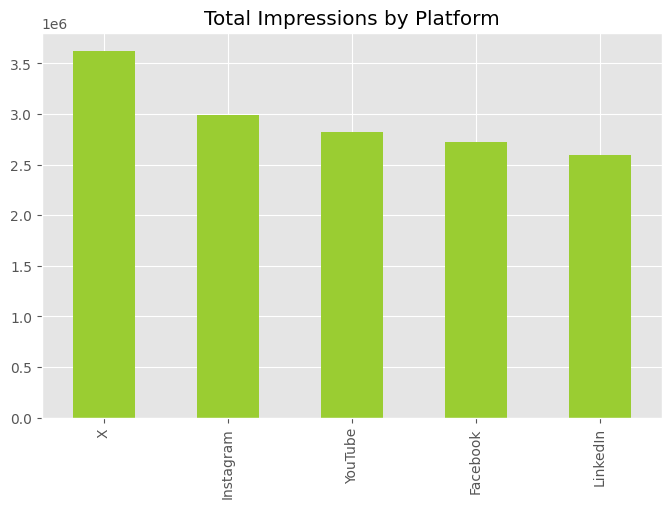

In [91]:
platform_imp = df.groupby("Platform")["Impressions"].sum().sort_values(ascending=False)

print(platform_imp)

platform_imp.plot(kind="bar", figsize=(8,5),color="yellowgreen")
plt.title("Total Impressions by Platform")
plt.ylabel("")
plt.xlabel("")
plt.show()

Platform
X            3712
Instagram    3178
YouTube      3162
Facebook     3068
LinkedIn     2902
Name: New_Followers_Gained, dtype: int64


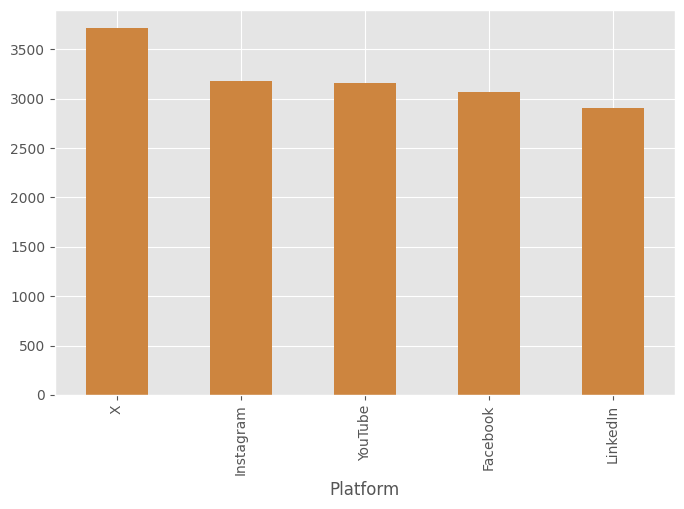

In [90]:
followers_platform = df.groupby("Platform")["New_Followers_Gained"].sum().sort_values(ascending=False)

print(followers_platform)

followers_platform.plot(kind="bar", figsize=(8,5),color="peru")
plt.title("")
plt.ylabel("")
plt.show()

Month Name
August       2241
January      1891
May          1800
April        1728
July         1539
February     1492
September    1462
March        1407
October      1348
June         1114
Name: New_Followers_Gained, dtype: int64


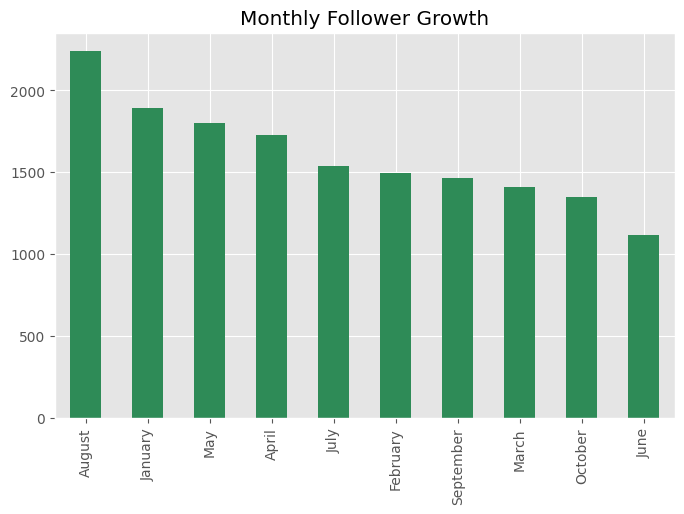

In [89]:
month_growth = df.groupby("Month Name")["New_Followers_Gained"].sum().sort_values(ascending=False)

print(month_growth)

month_growth.plot(kind="bar", figsize=(8,5),color="seagreen")
plt.title("Monthly Follower Growth")
plt.ylabel("")
plt.xlabel("")
plt.show()

In [46]:
unfollow_platform_category = (
    df.groupby(["Platform", "Content_Category"])["Unfollows"]
      .sum()
      .reset_index()
)

highest_unfollow_by_platform = (
    unfollow_platform_category.loc[
        unfollow_platform_category.groupby("Platform")["Unfollows"].idxmax()
    ]
)

print(highest_unfollow_by_platform.rename(columns={"Unfollows":"Total_Unfollows"}))


     Platform Content_Category  Total_Unfollows
2    Facebook         Personal              145
6   Instagram             Meme              181
11   LinkedIn             Meme              142
17          X         Personal              184
22    YouTube         Personal              145


Post_Type
Video       95%
Reel        86%
Short       86%
Carousel    79%
Image       77%
Name: Engagement_Rate_%, dtype: object


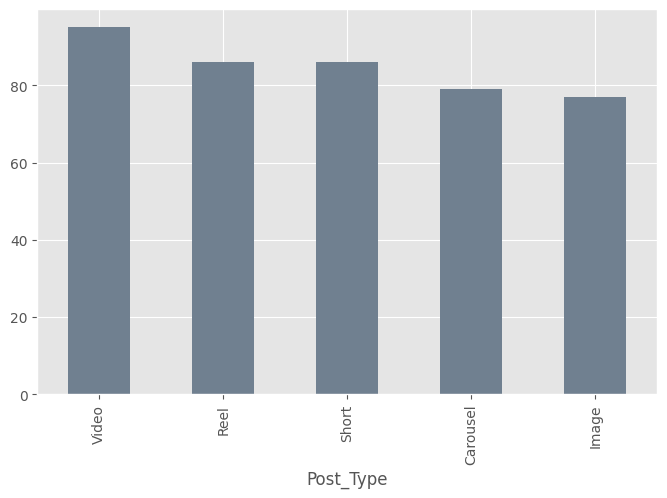

In [88]:
post_eng_rate = df.groupby("Post_Type")["Engagement_Rate_%"].mean().sort_values(ascending=False)
post_eng_rate = post_eng_rate.round(0).astype(int)

print(post_eng_rate.astype(str) + "%")

post_eng_rate.plot(kind="bar", figsize=(8,5),color="slategray")
plt.title("")
plt.ylabel("")
plt.show()

Platform
Facebook     91%
LinkedIn     64%
YouTube      64%
Instagram    60%
X            54%
Name: Engagement Efficiency (%), dtype: object


Text(0.5, 0, '')

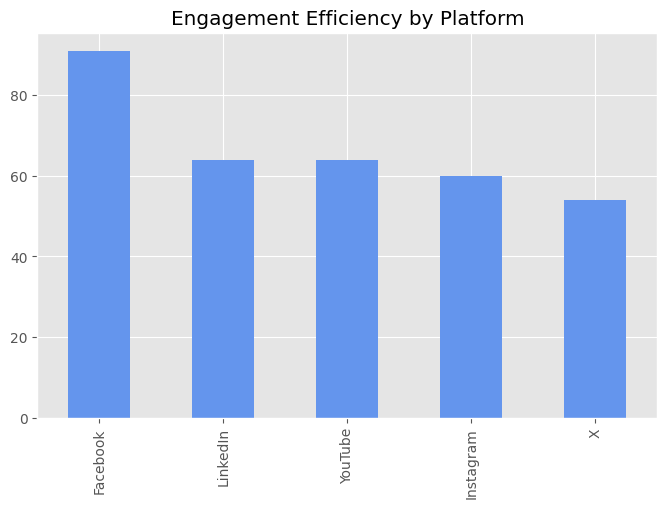

In [87]:
conversion = (df.groupby("Platform")["Engagement_per_Impression"]
                .mean()
                .sort_values(ascending=False) * 100)
conversion = conversion.round(0).astype(int)

print(conversion.rename("Engagement Efficiency (%)").astype(str) + "%")

ax = conversion.plot(kind="bar", figsize=(8,5), color="cornflowerblue")

plt.title("Engagement Efficiency by Platform")
plt.ylabel("")
plt.xlabel("")

Content_Category  Education  Meme  Personal  Promotion  Trend
Platform                                                     
Facebook               4010  4630      4653       4253   5345
Instagram              4429  4674      4034       4065   4856
LinkedIn               4990  4159      4715       4313   3809
X                      5080  3901      5383       3940   4538
YouTube                5046  3924      4427       3966   5522


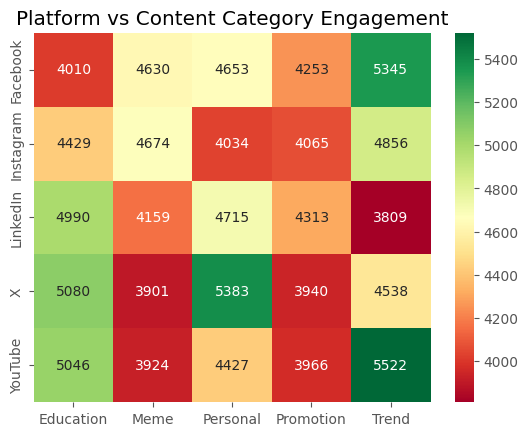

In [86]:
pivot_category = pd.pivot_table(
    df,
    values="Total_Engagement",
    index="Platform",
    columns="Content_Category",
    aggfunc="mean"
)
pivot_category = pivot_category.round(0).astype(int)
print(pivot_category)

sns.heatmap(pivot_category, annot=True, cmap="RdYlGn",fmt="d")
plt.title("Platform vs Content Category Engagement")
plt.xlabel("")
plt.ylabel("")
plt.show()

top_profile_posts = df.sort_values("Profile_Visits", ascending=False)[
    ["Post_Id","Platform","Post_Type","Profile_Visits"]
].head(5)

print(top_profile_posts)

Platform
Facebook     22%
LinkedIn     18%
YouTube      16%
X            14%
Instagram    14%
Name: Follower_Growth_Rate, dtype: object


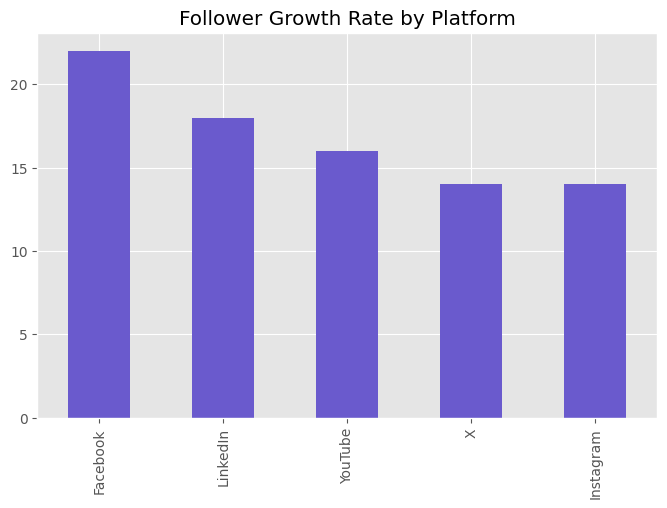

In [77]:
growth_rate = (df.groupby("Platform")["Follower_Growth_Rate"].mean().sort_values(ascending=False) * 10000)
growth_rate = growth_rate.round(2).astype(int)
print(growth_rate.astype(str) + "%")

growth_rate.plot(kind="bar", figsize=(8,5),color="slateblue")
plt.title("Follower Growth Rate by Platform")
plt.xlabel("")
plt.ylabel("")
plt.show()

Content_Category
Meme         3841
Personal     3384
Promotion    3080
Education    3002
Trend        2715
Name: New_Followers_Gained, dtype: int64


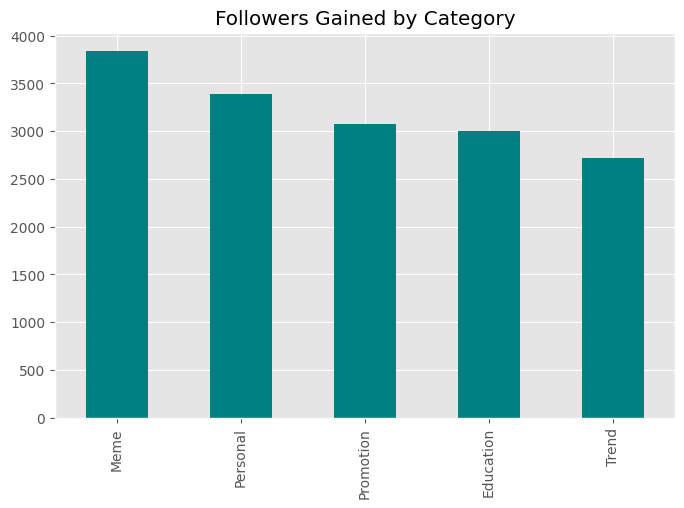

In [69]:
cat_follow = df.groupby("Content_Category")["New_Followers_Gained"].sum().sort_values(ascending=False)

print(cat_follow)

cat_follow.plot(kind="bar", figsize=(8,5),color="teal")
plt.title("Followers Gained by Category")
plt.xlabel("")
plt.ylabel("")
plt.show()

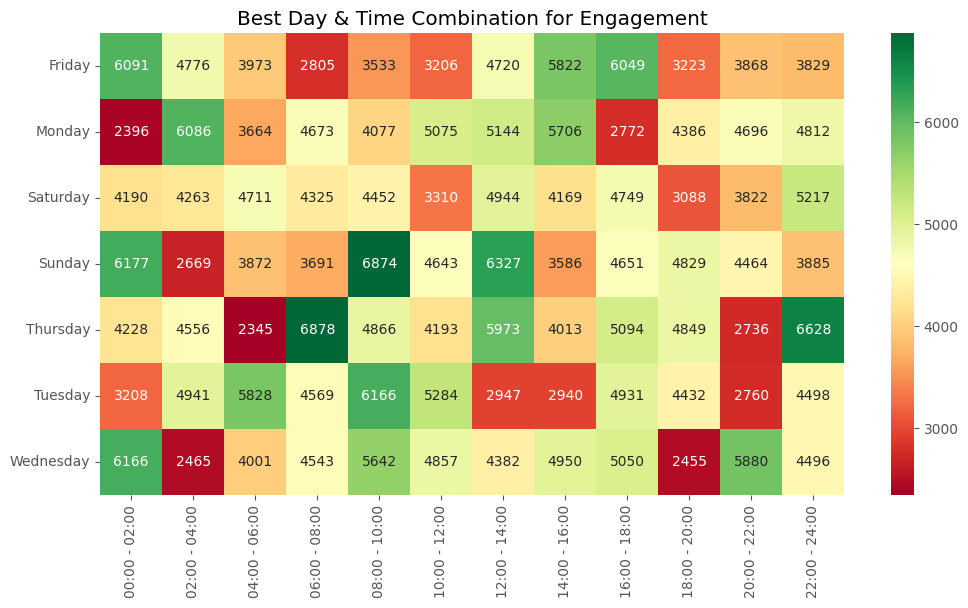

In [53]:
pivot_time_day = pd.pivot_table(
    df,
    values="Total_Engagement",
    index="Day_of_Week",
    columns="Time Slot(2hr)",
    aggfunc="mean"
)
pivot_time_day = pivot_time_day.round(0).astype(int)
plt.figure(figsize=(12,6))

sns.heatmap(pivot_time_day, annot=True, cmap="RdYlGn",fmt="d")

plt.title("Best Day & Time Combination for Engagement")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [54]:
top_posts = df.sort_values("Total_Engagement", ascending=False).head(10)

top_posts[["Post_Id","Platform","Post_Type","Content_Category","Total_Engagement"]]

,Post_Id,Platform,Post_Type,Content_Category,Total_Engagement
158,X069,X,Carousel,Education,10196
411,YT002,YouTube,Carousel,Education,10099
245,YT029,YouTube,Short,Trend,9964
230,IG071,Instagram,Video,Personal,9710
204,YT052,YouTube,Video,Promotion,9706
537,FB053,Facebook,Image,Personal,9671
409,IG007,Instagram,Short,Meme,9620
414,IG033,Instagram,Reel,Trend,9613
385,X092,X,Reel,Meme,9580
517,LI042,LinkedIn,Reel,Education,9524
